In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../Process Outliers/Outliers_Processed_Leads.csv")


In [3]:
df


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,Tags,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity
0,API,Chat,No,No,0,0.0,0,0.00,Page Visited on Website,Not Specified,Unemployed,Interested in other courses,Not Specified,Not Specified,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.50,Email Opened,Not Specified,Unemployed,Ringing,Not Specified,Not Specified,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.00,Email Opened,Business Administration,Student,Will revert after reading the email,Potential Lead,Mumbai,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.00,Unreachable,Marketing & Advertising,Unemployed,Ringing,Not Specified,Mumbai,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.00,Converted to Lead,Not Specified,Unemployed,Will revert after reading the email,Not Specified,Mumbai,No,Modified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7685,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,Other,IT Projects Management,Unemployed,Will revert after reading the email,Potential Lead,Mumbai,No,Other
7686,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,SMS Sent,Marketing & Advertising,Unemployed,invalid number,Potential Lead,Mumbai,Yes,SMS Sent
7687,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,SMS Sent,Business Administration,Unemployed,invalid number,Potential Lead,Mumbai,Yes,SMS Sent
7688,Landing Page Submission,Google,No,No,1,3.0,499,3.00,SMS Sent,Human Resource Management,Not Specified,Not Specified,Not Specified,Other Metro Cities,No,SMS Sent


In [4]:
print(pd.crosstab(df['Tags'], df['Converted'], normalize='index'))

df.drop(columns=['Tags'], inplace=True)


Converted                                   0         1
Tags                                                   
Already a student                    0.984456  0.015544
Busy                                 0.428571  0.571429
Closed by Horizzon                   0.006154  0.993846
Graduation in progress               0.934579  0.065421
Interested  in full time MBA         0.973684  0.026316
Interested in other courses          0.973214  0.026786
Lost to EINS                         0.108108  0.891892
Not Specified                        0.743986  0.256014
Not doing further education          0.990000  0.010000
Ringing                              0.969561  0.030439
Will Revert                          0.583333  0.416667
Will revert after reading the email  0.035135  0.964865
invalid number                       0.978836  0.021164
switched off                         0.982979  0.017021


In [5]:
# Xem kiểu dữ liệu từng cột
print(df.dtypes)

# Phân loại cột category và continuous
category_cols = []
continuous_cols = []

for col in df.columns:
    # Nếu là object hoặc có ít giá trị unique thì xem là category
    if df[col].dtype == 'object' or df[col].nunique() < 20:
        if col != 'TotalVisits':  # Bỏ qua cột target và cột TotalVisits vì nó là continuous
            category_cols.append(col)
    else:
        continuous_cols.append(col)

print("Categorical columns:")
print(category_cols)

print("\nContinuous columns:")
continuous_cols.append('TotalVisits')  # Thêm cột TotalVisits vào danh sách continuous
print(continuous_cols)


Lead Origin                                object
Lead Source                                object
Do Not Email                               object
Do Not Call                                object
Converted                                   int64
TotalVisits                               float64
Total Time Spent on Website                 int64
Page Views Per Visit                      float64
Last Activity                              object
Specialization                             object
What is your current occupation            object
Lead Profile                               object
City                                       object
A free copy of Mastering The Interview     object
Last Notable Activity                      object
dtype: object
Categorical columns:
['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'Last Activity', 'Specialization', 'What is your current occupation', 'Lead Profile', 'City', 'A free copy of Mastering The Interview', 'Las

In [6]:
labels = df['Converted']


Skewness Checking

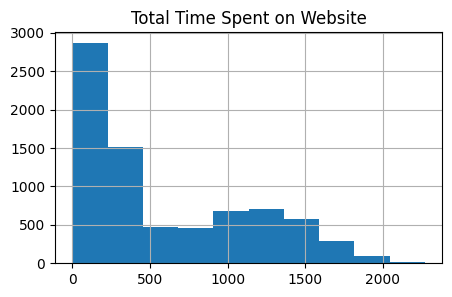

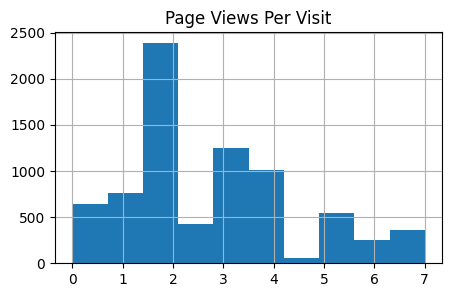

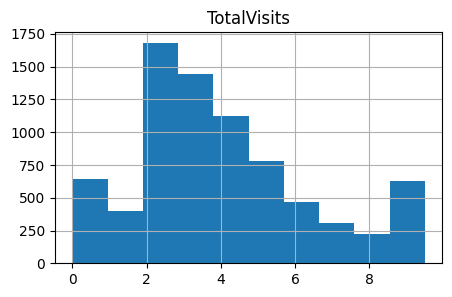

In [7]:
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure(figsize=(5, 3))
    df[col].hist(bins=10)
    plt.title(col)
    plt.show()


In [8]:
# Kiểm tra skewness
for col in continuous_cols:
    skewness = df[col].skew()
    print(f"Skewness of {col}: {skewness}")


Skewness of Total Time Spent on Website: 0.7318973584459149
Skewness of Page Views Per Visit: 0.6563151406884671
Skewness of TotalVisits: 0.7290377303080695


Dữ liệu không bị quá lệch nếu giá trị tuyệt đối của hệ số skewness nhỏ hơn 1. Nếu hệ số skewness lớn hơn 1 hoặc nhỏ hơn -1, dữ liệu được coi là bị lệch mạnh. Nếu hệ số skewness nằm giữa -1 và -0.5 hoặc giữa 0.5 và 1, dữ liệu được coi là bị lệch nhẹ. Nếu hệ số skewness nằm giữa -0.5 và 0.5, dữ liệu được coi là gần như đối xứng.

# **1. Encoding các cột category**

In [9]:
# Tạo bản sao để không làm thay đổi df gốc
df_encoded = df.copy() # không làm thay đổi thứ tự cột gốc


In [10]:
df_encoded


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity
0,API,Chat,No,No,0,0.0,0,0.00,Page Visited on Website,Not Specified,Unemployed,Not Specified,Not Specified,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.50,Email Opened,Not Specified,Unemployed,Not Specified,Not Specified,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.00,Email Opened,Business Administration,Student,Potential Lead,Mumbai,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.00,Unreachable,Marketing & Advertising,Unemployed,Not Specified,Mumbai,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.00,Converted to Lead,Not Specified,Unemployed,Not Specified,Mumbai,No,Modified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7685,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,Other,IT Projects Management,Unemployed,Potential Lead,Mumbai,No,Other
7686,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,SMS Sent,Marketing & Advertising,Unemployed,Potential Lead,Mumbai,Yes,SMS Sent
7687,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,SMS Sent,Business Administration,Unemployed,Potential Lead,Mumbai,Yes,SMS Sent
7688,Landing Page Submission,Google,No,No,1,3.0,499,3.00,SMS Sent,Human Resource Management,Not Specified,Not Specified,Other Metro Cities,No,SMS Sent


In [11]:
df


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity
0,API,Chat,No,No,0,0.0,0,0.00,Page Visited on Website,Not Specified,Unemployed,Not Specified,Not Specified,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.50,Email Opened,Not Specified,Unemployed,Not Specified,Not Specified,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.00,Email Opened,Business Administration,Student,Potential Lead,Mumbai,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.00,Unreachable,Marketing & Advertising,Unemployed,Not Specified,Mumbai,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.00,Converted to Lead,Not Specified,Unemployed,Not Specified,Mumbai,No,Modified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7685,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,Other,IT Projects Management,Unemployed,Potential Lead,Mumbai,No,Other
7686,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,SMS Sent,Marketing & Advertising,Unemployed,Potential Lead,Mumbai,Yes,SMS Sent
7687,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,SMS Sent,Business Administration,Unemployed,Potential Lead,Mumbai,Yes,SMS Sent
7688,Landing Page Submission,Google,No,No,1,3.0,499,3.00,SMS Sent,Human Resource Management,Not Specified,Not Specified,Other Metro Cities,No,SMS Sent


In [12]:
from sklearn.preprocessing import LabelEncoder

# Lưu lại encoder của từng cột nếu sau này cần inverse_transform
label_encoders = {}

for col in category_cols:
    le = LabelEncoder()
    
    # Chuyển về string để tránh lỗi nếu có NaN hoặc kiểu mixed
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    
    label_encoders[col] = le

# Kết quả
df_encoded.head()


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity
0,0,0,0,0,0,0.0,0,0.0,7,10,3,0,1,0,2
1,0,3,0,0,0,5.0,674,2.5,3,10,3,0,1,0,1
2,1,1,0,0,1,2.0,1532,2.0,3,1,2,3,0,1,1
3,1,1,0,0,0,1.0,305,1.0,10,9,3,0,0,0,2
4,1,2,0,0,1,2.0,1428,1.0,0,10,3,0,0,0,2


In [13]:
for col, le in label_encoders.items():
    print(f"\nColumn: {col}")
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(mapping)



Column: Lead Origin
{'API': 0, 'Landing Page Submission': 1, 'Lead Add Form': 2, 'Other': 3}

Column: Lead Source
{'Chat': 0, 'Direct Traffic': 1, 'Google': 2, 'Organic Search': 3, 'Other': 4, 'Referral': 5}

Column: Do Not Email
{'No': 0, 'Yes': 1}

Column: Do Not Call
{'No': 0, 'Yes': 1}

Column: Converted
{'0': 0, '1': 1}

Column: Last Activity
{'Converted to Lead': 0, 'Email Bounced': 1, 'Email Link Clicked': 2, 'Email Opened': 3, 'Form Submitted on Website': 4, 'Olark Chat Conversation': 5, 'Other': 6, 'Page Visited on Website': 7, 'SMS Sent': 8, 'Unknown': 9, 'Unreachable': 10}

Column: Specialization
{'Banking, Investment And Insurance': 0, 'Business Administration': 1, 'E-Commerce': 2, 'Finance & Banking': 3, 'Healthcare Management': 4, 'Hospitality & Tourism': 5, 'Human Resource Management': 6, 'IT Projects Management': 7, 'International Business': 8, 'Marketing & Advertising': 9, 'Not Specified': 10, 'Operations Management': 11, 'Other': 12, 'Retail Management': 13, 'Supply 

# **2. Ma trận tương quan Pearson**

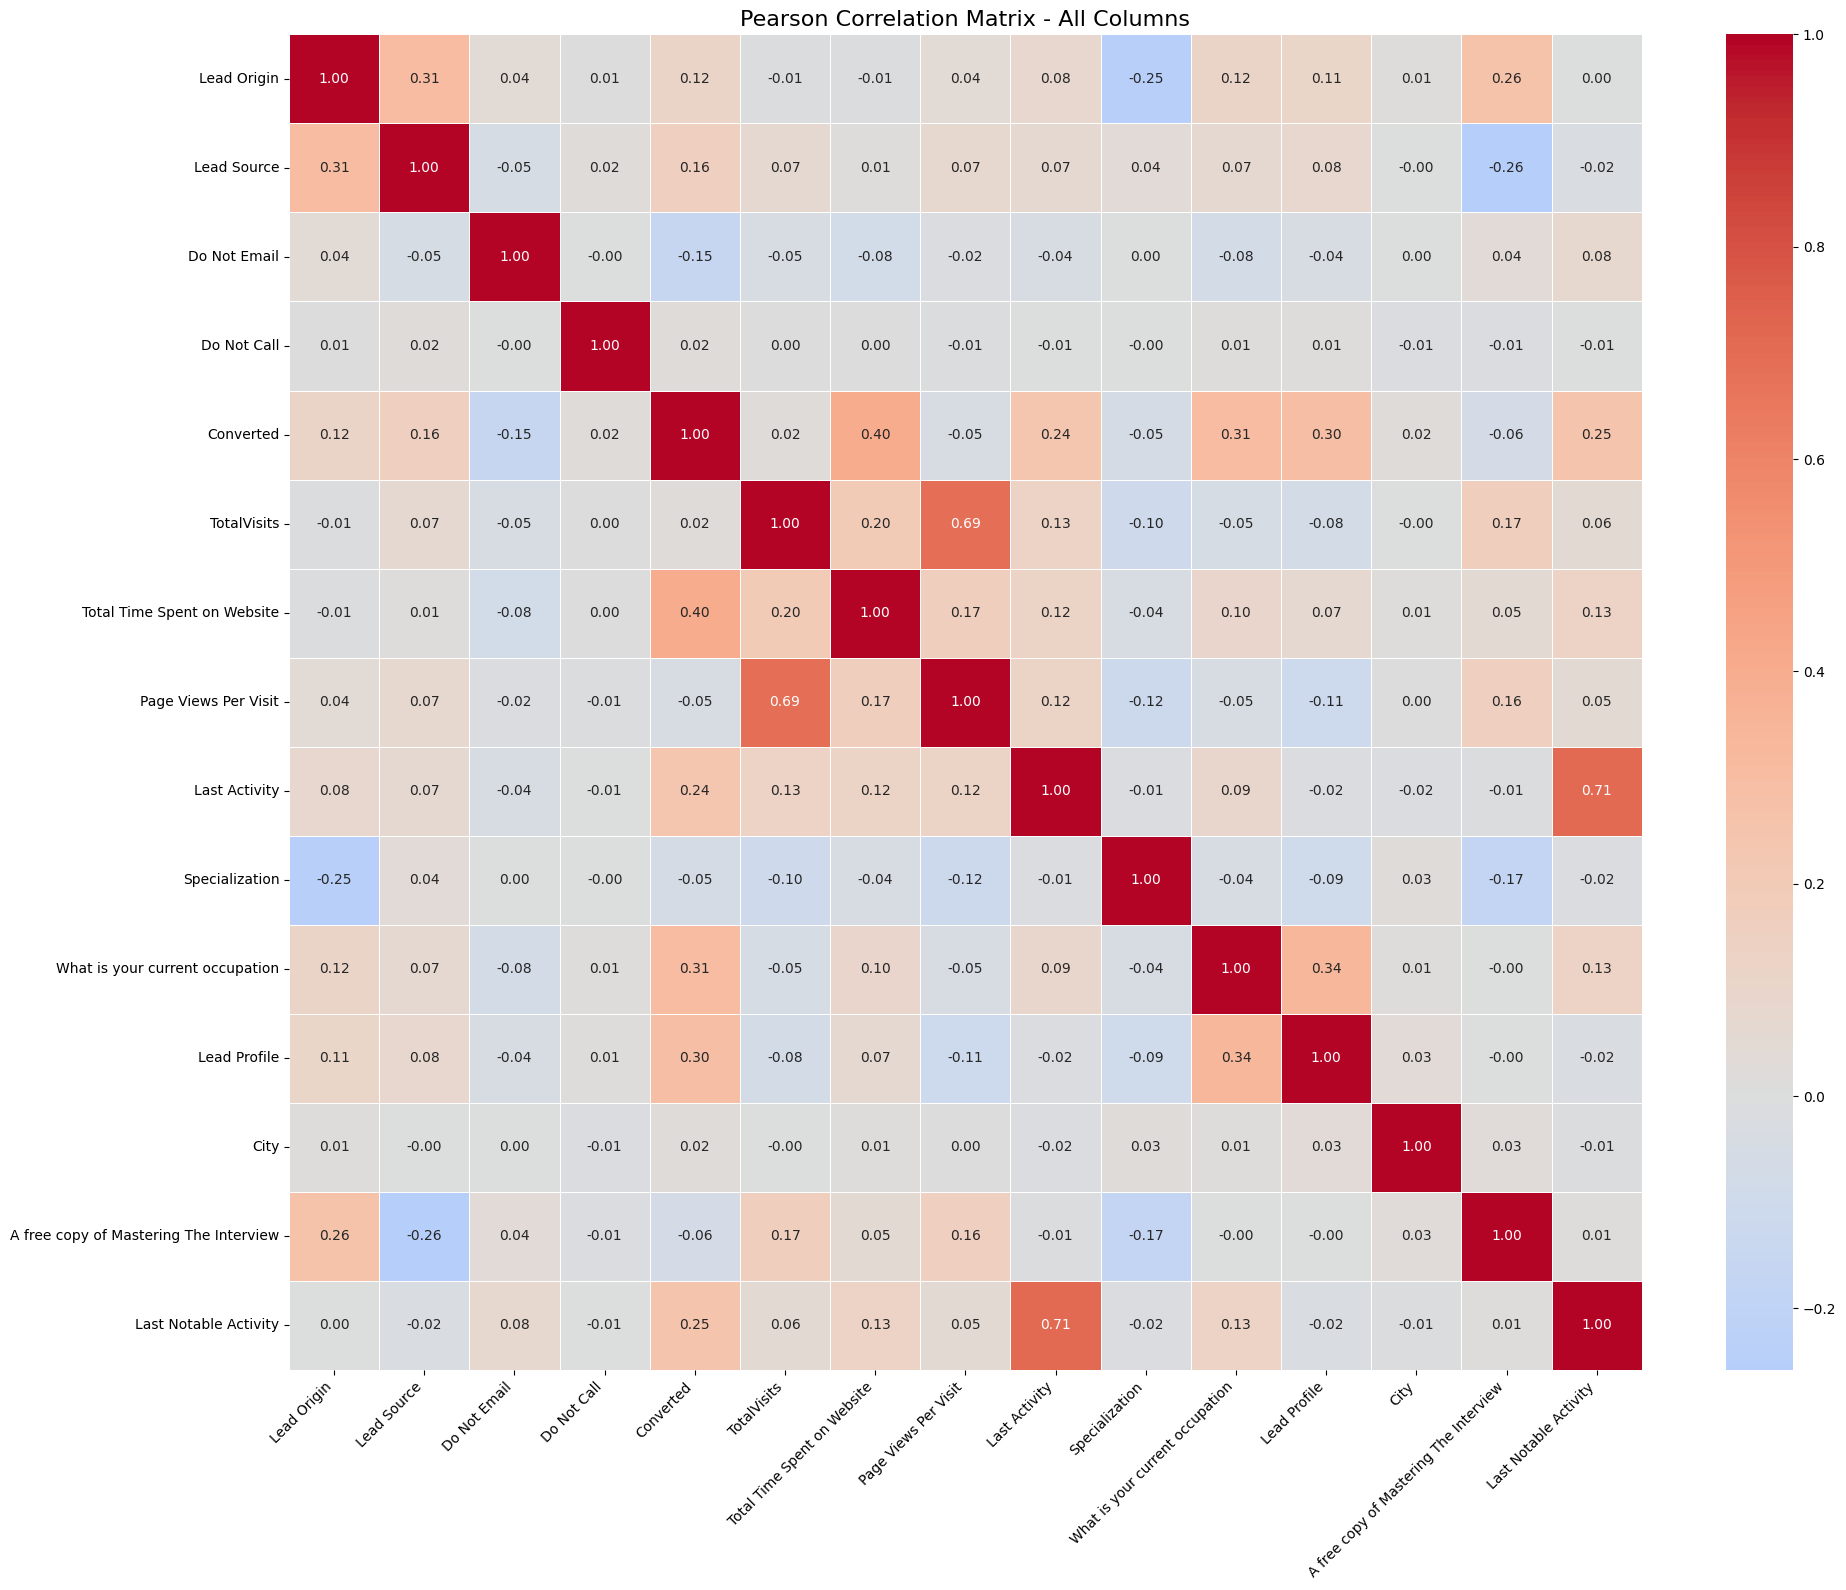

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nếu muốn lấy toàn bộ cột, kể cả category đã encode
corr_matrix = df_encoded.corr(method='pearson', numeric_only=True)

# Vẽ heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title('Pearson Correlation Matrix - All Columns', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# **3. Feature Engineering**

## Polynomial Features

In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

temp = poly.fit_transform(df_encoded[continuous_cols])


In [16]:
continuous_cols


['Total Time Spent on Website', 'Page Views Per Visit', 'TotalVisits']

In [17]:
pd.DataFrame(poly.powers_, columns=['tttspow_degree',  
                                  'pvps_degree',
                                  'totalvisits_degree'])


,tttspow_degree,pvps_degree,totalvisits_degree
0,1,0,0
1,0,1,0
2,0,0,1
3,1,1,0
4,1,0,1
5,0,1,1


In [18]:
intr_features = pd.DataFrame(temp, columns=['Total Time Spent on Website', 'Page Views Per Visit',  
                                           'TotalVisits', 
                                           'ttspow_pvps',  
                                           'tttspow_totalvisits',
                                           'pvps_totalvisits'])
intr_features.head(5)


,Total Time Spent on Website,Page Views Per Visit,TotalVisits,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits
0,0.0,0.0,0.0,0.0,0.0,0.0
1,674.0,2.5,5.0,1685.0,3370.0,12.5
2,1532.0,2.0,2.0,3064.0,3064.0,4.0
3,305.0,1.0,1.0,305.0,305.0,1.0
4,1428.0,1.0,2.0,1428.0,2856.0,2.0


In [19]:
intr_features.drop(columns=['Total Time Spent on Website', 'Page Views Per Visit', 'TotalVisits'], inplace=True)
intr_features.head(5)


,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits
0,0.0,0.0,0.0
1,1685.0,3370.0,12.5
2,3064.0,3064.0,4.0
3,305.0,305.0,1.0
4,1428.0,2856.0,2.0


In [20]:
X = pd.concat([df_encoded, intr_features], axis=1)
X.head()


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits
0,0,0,0,0,0,0.0,0,0.0,7,10,3,0,1,0,2,0.0,0.0,0.0
1,0,3,0,0,0,5.0,674,2.5,3,10,3,0,1,0,1,1685.0,3370.0,12.5
2,1,1,0,0,1,2.0,1532,2.0,3,1,2,3,0,1,1,3064.0,3064.0,4.0
3,1,1,0,0,0,1.0,305,1.0,10,9,3,0,0,0,2,305.0,305.0,1.0
4,1,2,0,0,1,2.0,1428,1.0,0,10,3,0,0,0,2,1428.0,2856.0,2.0


## Manual Feature Engineering

#### Đặc trưng "Time_Per_Page"

In [21]:
X["Time_Per_Page"] = (
    X["Total Time Spent on Website"] /
    (X["Page Views Per Visit"] + 1)
)
X.head()


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page
0,0,0,0,0,0,0.0,0,0.0,7,10,3,0,1,0,2,0.0,0.0,0.0,0.000000
1,0,3,0,0,0,5.0,674,2.5,3,10,3,0,1,0,1,1685.0,3370.0,12.5,192.571429
2,1,1,0,0,1,2.0,1532,2.0,3,1,2,3,0,1,1,3064.0,3064.0,4.0,510.666667
3,1,1,0,0,0,1.0,305,1.0,10,9,3,0,0,0,2,305.0,305.0,1.0,152.500000
4,1,2,0,0,1,2.0,1428,1.0,0,10,3,0,0,0,2,1428.0,2856.0,2.0,714.000000


Đặc trưng "Time_Per_Page" được tạo ra bằng cách chia "Total Time Spent on Website" cho "Page Views Per Visit" cộng thêm 1 (để tránh chia cho 0). Đây là một đặc trưng mới có thể giúp mô hình hiểu rõ hơn về thời gian trung bình mà người dùng dành cho mỗi trang trên website, từ đó có thể cải thiện hiệu suất dự đoán.

#### Đặc trưng "Time Per Visit"

In [22]:
X["Time_Per_Visit"] = (
    X["Total Time Spent on Website"] /
    (X["TotalVisits"] + 1)
)
X.head()


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit
0,0,0,0,0,0,0.0,0,0.0,7,10,3,0,1,0,2,0.0,0.0,0.0,0.000000,0.000000
1,0,3,0,0,0,5.0,674,2.5,3,10,3,0,1,0,1,1685.0,3370.0,12.5,192.571429,112.333333
2,1,1,0,0,1,2.0,1532,2.0,3,1,2,3,0,1,1,3064.0,3064.0,4.0,510.666667,510.666667
3,1,1,0,0,0,1.0,305,1.0,10,9,3,0,0,0,2,305.0,305.0,1.0,152.500000,152.500000
4,1,2,0,0,1,2.0,1428,1.0,0,10,3,0,0,0,2,1428.0,2856.0,2.0,714.000000,476.000000


Đặc trưng "Time_Per_Visit" được tạo ra bằng cách chia "Total Time Spent on Website" cho "Total Visits" cộng thêm 1 (để tránh chia cho 0). Đây là một đặc trưng mới có thể giúp mô hình hiểu rõ hơn về hành vi của người dùng trên trang web, cụ thể là thời gian trung bình mà họ dành cho mỗi lần truy cập.

#### Đặc trưng "Engagement_Score"

In [23]:
X["Engagement_Score"] = (
    X["TotalVisits"] * 0.25 +
    X["Page Views Per Visit"] * 0.25 +
    X["Total Time Spent on Website"] * 0.5
)
X.head()


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,...,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit,Engagement_Score
0,0,0,0,0,0,0.0,0,0.0,7,10,...,0,1,0,2,0.0,0.0,0.0,0.000000,0.000000,0.000
1,0,3,0,0,0,5.0,674,2.5,3,10,...,0,1,0,1,1685.0,3370.0,12.5,192.571429,112.333333,338.875
2,1,1,0,0,1,2.0,1532,2.0,3,1,...,3,0,1,1,3064.0,3064.0,4.0,510.666667,510.666667,767.000
3,1,1,0,0,0,1.0,305,1.0,10,9,...,0,0,0,2,305.0,305.0,1.0,152.500000,152.500000,153.000
4,1,2,0,0,1,2.0,1428,1.0,0,10,...,0,0,0,2,1428.0,2856.0,2.0,714.000000,476.000000,714.750


Đặc trưng "Engagement Score" được tạo ra bằng cách kết hợp các đặc trưng "TotalVisits", "Page Views Per Visit" và "Total Time Spent on Website" với các trọng số khác nhau (0.25, 0.25 và 0.5). Đây là một đặc trưng tổng hợp có thể giúp mô hình đánh giá mức độ tương tác của người dùng với trang web, từ đó cải thiện hiệu suất dự đoán.

Các hệ số được đánh giá dựa trên độ tương quan Pearson giữa các biến với biến mục tiêu "Converted"

#### Đặc trưng "Engagement Level"


In [24]:
X["Engagement_Level"] = (
    (X["TotalVisits"] > X["TotalVisits"].median()).astype(int) +
    (X["Total Time Spent on Website"] > X["Total Time Spent on Website"].median()).astype(int) +
    (X["Page Views Per Visit"] > X["Page Views Per Visit"].median()).astype(int)
)
X.head()


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,...,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit,Engagement_Score,Engagement_Level
0,0,0,0,0,0,0.0,0,0.0,7,10,...,1,0,2,0.0,0.0,0.0,0.000000,0.000000,0.000,0
1,0,3,0,0,0,5.0,674,2.5,3,10,...,1,0,1,1685.0,3370.0,12.5,192.571429,112.333333,338.875,3
2,1,1,0,0,1,2.0,1532,2.0,3,1,...,0,1,1,3064.0,3064.0,4.0,510.666667,510.666667,767.000,1
3,1,1,0,0,0,1.0,305,1.0,10,9,...,0,0,2,305.0,305.0,1.0,152.500000,152.500000,153.000,0
4,1,2,0,0,1,2.0,1428,1.0,0,10,...,0,0,2,1428.0,2856.0,2.0,714.000000,476.000000,714.750,1


Đặc trưng "Engagement Level" được tạo ra bằng cách đánh giá xem mỗi đặc trưng "TotalVisits", "Total Time Spent on Website" và "Page Views Per Visit" có lớn hơn giá trị trung vị của chúng hay không. Mỗi đặc trưng sẽ đóng góp 1 điểm nếu nó lớn hơn giá trị trung vị, và tổng điểm sẽ được sử dụng để xác định mức độ tương tác của người dùng. Đây là một cách tiếp cận đơn giản nhưng hiệu quả để phân loại người dùng thành các nhóm tương tác khác nhau, từ đó giúp mô hình dự đoán tốt hơn về khả năng chuyển đổi của họ.

# **4. Train Test Split**

In [25]:
X


,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,...,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit,Engagement_Score,Engagement_Level
0,0,0,0,0,0,0.0,0,0.00,7,10,...,1,0,2,0.00,0.0,0.00,0.000000,0.000000,0.0000,0
1,0,3,0,0,0,5.0,674,2.50,3,10,...,1,0,1,1685.00,3370.0,12.50,192.571429,112.333333,338.8750,3
2,1,1,0,0,1,2.0,1532,2.00,3,1,...,0,1,1,3064.00,3064.0,4.00,510.666667,510.666667,767.0000,1
3,1,1,0,0,0,1.0,305,1.00,10,9,...,0,0,2,305.00,305.0,1.00,152.500000,152.500000,153.0000,0
4,1,2,0,0,1,2.0,1428,1.00,0,10,...,0,0,2,1428.00,2856.0,2.00,714.000000,476.000000,714.7500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7685,1,1,1,0,1,8.0,1845,2.67,6,7,...,0,0,4,4926.15,14760.0,21.36,502.724796,205.000000,925.1675,3
7686,1,1,0,0,0,2.0,238,2.00,8,9,...,0,1,6,476.00,476.0,4.00,79.333333,79.333333,120.0000,0
7687,1,1,1,0,0,2.0,199,2.00,8,1,...,0,1,6,398.00,398.0,4.00,66.333333,66.333333,100.5000,0
7688,1,2,0,0,1,3.0,499,3.00,8,6,...,3,0,6,1497.00,1497.0,9.00,124.750000,124.750000,251.0000,2


In [26]:
labels


0       0
1       0
2       1
3       0
4       1
       ..
7685    1
7686    0
7687    0
7688    1
7689    1
Name: Converted, Length: 7690, dtype: int64

In [27]:
X = X.drop('Converted', axis=1)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42)


In [29]:
X_train


,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,...,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit,Engagement_Score,Engagement_Level
1536,0,2,0,0,4.0,262,4.00,8,1,3,...,3,0,2,1048.0,1048.0,16.00,52.400000,52.400000,133.0000,2
4660,1,1,0,0,2.0,1417,2.00,8,9,3,...,0,1,6,2834.0,2834.0,4.00,472.333333,472.333333,709.5000,1
4410,0,2,0,0,2.0,535,2.00,3,10,2,...,1,0,1,1070.0,1070.0,4.00,178.333333,178.333333,268.5000,1
501,1,3,0,0,6.0,361,3.00,3,12,0,...,3,1,1,1083.0,2166.0,18.00,90.250000,51.571429,182.7500,3
2432,1,2,0,0,3.0,393,3.00,5,3,3,...,0,0,2,1179.0,1179.0,9.00,98.250000,98.250000,198.0000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5226,1,1,0,0,8.0,178,4.00,3,0,2,...,0,1,1,712.0,1424.0,32.00,35.600000,19.777778,92.0000,2
5390,0,2,0,0,5.0,1288,1.25,7,9,4,...,1,0,2,1610.0,6440.0,6.25,572.444444,214.666667,645.5625,2
860,1,1,0,0,4.0,171,2.00,3,10,3,...,1,1,1,342.0,684.0,8.00,57.000000,34.200000,87.0000,1
7603,1,2,0,0,5.0,262,5.00,3,9,0,...,0,0,2,1310.0,1310.0,25.00,43.666667,43.666667,133.5000,2


In [30]:
y_train


1536    1
4660    0
4410    0
501     0
2432    0
       ..
5226    1
5390    1
860     0
7603    1
7270    0
Name: Converted, Length: 6152, dtype: int64

In [31]:
X_test


,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,...,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit,Engagement_Score,Engagement_Level
2389,1,1,0,0,8.0,1484,7.0,8,9,3,...,0,1,6,10388.0,11872.0,56.00,185.500000,164.888889,745.75,3
3034,1,3,0,0,3.0,424,3.0,3,1,3,...,0,1,1,1272.0,1272.0,9.00,106.000000,106.000000,213.50,2
6973,1,1,1,0,2.0,152,2.0,1,12,3,...,2,0,2,304.0,304.0,4.00,50.666667,50.666667,77.00,0
6587,0,3,1,0,9.5,1334,6.5,8,4,3,...,3,1,6,8671.0,12673.0,61.75,177.866667,127.047619,671.00,3
5476,1,2,1,0,4.0,132,4.0,8,11,3,...,3,0,6,528.0,528.0,16.00,26.400000,26.400000,68.00,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2,5,0,0,3.0,785,2.0,6,10,3,...,1,0,2,1570.0,2355.0,6.00,261.666667,196.250000,393.75,1
5548,1,1,0,0,2.0,1294,2.0,3,9,3,...,0,1,1,2588.0,2588.0,4.00,431.333333,431.333333,648.00,1
1201,1,1,0,0,2.0,942,2.0,3,11,3,...,4,1,1,1884.0,1884.0,4.00,314.000000,314.000000,472.00,1
4047,1,1,0,0,3.0,1101,3.0,8,1,3,...,0,1,6,3303.0,3303.0,9.00,275.250000,275.250000,552.00,2


In [32]:
y_test


2389    1
3034    0
6973    0
6587    1
5476    0
       ..
188     1
5548    0
1201    1
4047    1
2939    1
Name: Converted, Length: 1538, dtype: int64

# **5. Scaling dữ liệu**

Tiến hành scale các cột count mới tạo ra bằng StandardScaler

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = continuous_cols + ['Time_Per_Page', 'Time_Per_Visit', 'Engagement_Score', 'Engagement_Level' ] + list(intr_features.columns)
print(cols_to_scale)
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


['Total Time Spent on Website', 'Page Views Per Visit', 'TotalVisits', 'Time_Per_Page', 'Time_Per_Visit', 'Engagement_Score', 'Engagement_Level', 'ttspow_pvps', 'tttspow_totalvisits', 'pvps_totalvisits']


In [34]:
X_train.head()


,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,...,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit,Engagement_Score,Engagement_Level
1536,0,2,0,0,0.084463,-0.590051,0.727134,8,1,3,...,3,0,2,-0.348459,-0.470097,0.180478,-0.657154,-0.569157,-0.588346,0.519462
4660,1,1,0,0,-0.711580,1.509340,-0.446186,8,9,3,...,0,1,6,0.516733,0.121566,-0.655659,1.760122,2.306901,1.506038,-0.424345
4410,0,2,0,0,-0.711580,-0.093831,-0.446186,3,10,2,...,1,0,1,-0.337802,-0.462809,-0.655659,0.067760,0.293341,-0.096084,-0.424345
501,1,3,0,0,0.880506,-0.410103,0.140474,3,12,0,...,3,1,1,-0.331504,-0.099728,0.319834,-0.439277,-0.574832,-0.407608,1.463268
2432,1,2,0,0,-0.313558,-0.351938,0.140474,5,3,3,...,0,0,2,-0.284999,-0.426700,-0.307269,-0.393226,-0.255137,-0.352206,0.519462


In [35]:
X_test


,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,...,City,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit,Engagement_Score,Engagement_Level
2389,1,1,0,0,1.676549,1.631123,2.487114,8,9,3,...,0,1,6,4.176118,3.115657,2.967599,0.109014,0.201262,1.637731,1.463268
3034,1,3,0,0,-0.313558,-0.295591,0.140474,3,1,3,...,0,1,1,-0.239947,-0.395891,-0.307269,-0.348614,-0.202059,-0.295895,0.519462
6973,1,1,1,0,-0.711580,-0.789993,-0.446186,1,12,3,...,2,0,2,-0.708875,-0.716568,-0.655659,-0.667131,-0.581028,-0.791790,-1.368151
6587,0,3,1,0,2.273581,1.358475,2.193784,8,4,3,...,3,1,6,3.344352,3.381011,3.368248,0.065074,-0.057907,1.366170,1.463268
5476,1,2,1,0,0.084463,-0.826346,0.727134,8,11,3,...,3,0,6,-0.600363,-0.642362,0.180478,-0.806818,-0.747227,-0.824486,0.519462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2,5,0,0,-0.313558,0.360583,-0.446186,6,10,3,...,1,0,2,-0.095587,-0.037117,-0.516303,0.547455,0.416049,0.358940,-0.424345
5548,1,1,0,0,-0.711580,1.285769,-0.446186,3,9,3,...,0,1,1,0.397563,0.040071,-0.655659,1.524113,2.026098,1.282612,-0.424345
1201,1,1,0,0,-0.711580,0.645954,-0.446186,3,11,3,...,4,1,1,0.056524,-0.193149,-0.655659,0.848703,1.222500,0.643217,-0.424345
4047,1,1,0,0,-0.313558,0.934961,0.140474,8,1,3,...,0,1,6,0.743931,0.276935,-0.307269,0.625645,0.957108,0.933851,0.519462


In [36]:
X_train['Converted'] = y_train
X_test['Converted'] = y_test
X_train.to_csv("Leads_Engineered_Scaled_Train.csv", index=False)
X_test.to_csv("Leads_Engineered_Scaled_Test.csv", index=False)


In [37]:
X_train


,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,...,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit,Engagement_Score,Engagement_Level,Converted
1536,0,2,0,0,0.084463,-0.590051,0.727134,8,1,3,...,0,2,-0.348459,-0.470097,0.180478,-0.657154,-0.569157,-0.588346,0.519462,1
4660,1,1,0,0,-0.711580,1.509340,-0.446186,8,9,3,...,1,6,0.516733,0.121566,-0.655659,1.760122,2.306901,1.506038,-0.424345,0
4410,0,2,0,0,-0.711580,-0.093831,-0.446186,3,10,2,...,0,1,-0.337802,-0.462809,-0.655659,0.067760,0.293341,-0.096084,-0.424345,0
501,1,3,0,0,0.880506,-0.410103,0.140474,3,12,0,...,1,1,-0.331504,-0.099728,0.319834,-0.439277,-0.574832,-0.407608,1.463268,0
2432,1,2,0,0,-0.313558,-0.351938,0.140474,5,3,3,...,0,2,-0.284999,-0.426700,-0.307269,-0.393226,-0.255137,-0.352206,0.519462,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5226,1,1,0,0,1.676549,-0.742734,0.727134,3,0,2,...,1,1,-0.511228,-0.345537,1.295326,-0.753860,-0.792581,-0.737296,0.519462,1
5390,0,2,0,0,0.482485,1.274863,-0.886181,7,9,4,...,0,2,-0.076209,1.316154,-0.498883,2.336395,0.542182,1.273757,0.519462,1
860,1,1,0,0,0.084463,-0.755457,-0.446186,3,10,3,...,1,1,-0.690467,-0.590682,-0.376947,-0.630675,-0.693806,-0.755461,-0.424345,0
7603,1,2,0,0,0.482485,-0.590051,1.313794,3,9,0,...,0,2,-0.221539,-0.383302,0.807580,-0.707426,-0.628970,-0.586530,0.519462,1


In [38]:
X_test


,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,...,A free copy of Mastering The Interview,Last Notable Activity,ttspow_pvps,tttspow_totalvisits,pvps_totalvisits,Time_Per_Page,Time_Per_Visit,Engagement_Score,Engagement_Level,Converted
2389,1,1,0,0,1.676549,1.631123,2.487114,8,9,3,...,1,6,4.176118,3.115657,2.967599,0.109014,0.201262,1.637731,1.463268,1
3034,1,3,0,0,-0.313558,-0.295591,0.140474,3,1,3,...,1,1,-0.239947,-0.395891,-0.307269,-0.348614,-0.202059,-0.295895,0.519462,0
6973,1,1,1,0,-0.711580,-0.789993,-0.446186,1,12,3,...,0,2,-0.708875,-0.716568,-0.655659,-0.667131,-0.581028,-0.791790,-1.368151,0
6587,0,3,1,0,2.273581,1.358475,2.193784,8,4,3,...,1,6,3.344352,3.381011,3.368248,0.065074,-0.057907,1.366170,1.463268,1
5476,1,2,1,0,0.084463,-0.826346,0.727134,8,11,3,...,0,6,-0.600363,-0.642362,0.180478,-0.806818,-0.747227,-0.824486,0.519462,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2,5,0,0,-0.313558,0.360583,-0.446186,6,10,3,...,0,2,-0.095587,-0.037117,-0.516303,0.547455,0.416049,0.358940,-0.424345,1
5548,1,1,0,0,-0.711580,1.285769,-0.446186,3,9,3,...,1,1,0.397563,0.040071,-0.655659,1.524113,2.026098,1.282612,-0.424345,0
1201,1,1,0,0,-0.711580,0.645954,-0.446186,3,11,3,...,1,1,0.056524,-0.193149,-0.655659,0.848703,1.222500,0.643217,-0.424345,1
4047,1,1,0,0,-0.313558,0.934961,0.140474,8,1,3,...,1,6,0.743931,0.276935,-0.307269,0.625645,0.957108,0.933851,0.519462,1


In [39]:
# Save scaler
import joblib
joblib.dump(scaler, 'leads_scaler.pkl')


['leads_scaler.pkl']

In [40]:
joblib.dump(cols_to_scale, "columns.pkl")


['columns.pkl']